# 0. Initialiseer - refresh external data en import libraries

### De df_dim_sensor tabel bevat de volgende informatie
- **locatie**            = de naam van de locatie waar de sensor is geplaats
- **device_name**        = de naam van de sensor die op de label van de fysieke sensor staat
- **datum_geplaatst**      = de datum waarop de sensor in de grond is geplaatst
- **datum_weggehaald**  = de datum waarop de sensor uit de grond is gehaald. Als deze datum na vandaag ligt, dan zit de sensor daar nog in de grond.
- **diepte_plaatsing**     = de diepte waarop de pinnen van de sensor in de grond zijn geplaats (15cm of 30cm diep)
- **leeftijd_plant**     = de leeftijd van de beplanting waar de de sensor is geplaats (0-1, 1-2 of 2-3 jaar)
- **soort_plant**        = de omschrijving van de beplanting waar de sensor is geplaatst
- **locatie_regio**      = de regio van de stad waar de sensor is geplaatst
- **extra_omschrijving** = een extra omschrijving van de locatie waar de sensor is geplaatst (bijv. in de berm, vlakbij bestrating, ..)
- **old**                = voor start van nieuwe project zijn er al sensoren geplaatst, deze hebben de indicatie 'old'. Van deze data weten we niet hoe betrouwbaar deze is.
- **device_name_org**    = voor het koppelen van de device_id's met de device_name's is de originele (= org) benaming aangepast om de koppeling te vereenvoudigen, daarom voor de zekerheid deze kolom wel behouden.
- **device_id**          = de id van de device zoals deze geregistreerd staat in de quantified portal. Middels de device id's kan de data via de quantified API opgehaald worden.

### De df_fact_sensor tabel bevat de volgende informatie
- **gateway_receive_time**  = tijdstip waarop sensor permittivity waarde is ontvangen
- **device**                = device_id waar de permittivity waarde vandaan komt
- **value**                 = de gemeten permittivity waarde

### De df_KNMI bevat de volgende informatie
- **YYYYMMDD**  = Datum (YYYY=jaar MM=maand DD=dag)
- **FG**        = Etmaalgemiddelde windsnelheid (in 0.1 m/s)
- (**TG**        = Etmaalgemiddelde temperatuur (in 0.1 graden Celsius)) --> <u>vervangen door Zusterhof</u>
- **SQ**        = Zonneschijnduur (in 0.1 uur) berekend uit de globale straling (-1 voor <0.05 uur)
- **DR**        = Duur van de neerslag (in 0.1 uur)
- (**RH**        = Etmaalsom van de neerslag (in 0.1 mm) (-1 voor <0.05 mm)) --> <u>vervangen door Zusterhof</u>
- **PG**        = Etmaalgemiddelde luchtdruk herleid tot zeeniveau (in 0.1 hPa) berekend uit 24 uurwaarden
- **NG**        = Etmaalgemiddelde bewolking (bedekkingsgraad van de bovenlucht in achtsten, 9=bovenlucht onzichtbaar)
- **UG**        = Etmaalgemiddelde relatieve vochtigheid (in procenten)
- **EV24**      = Referentiegewasverdamping (Makkink) (in 0.1 mm)

### De df_weerstation_leiden bevat de volgende informatie
- **datum**         = Datum meetwaarde
- **temperatuur**   = Etmaalgemiddelde temperatuur (in 0.1 graden Celsius)
- **neerslag**      = Etmaalsom van de neerslag (in mm) (-1 voor <0.05 mm)

### Notes
- De temperatuur en neerslag wordt van weerstation **Zusterhof** in Leiden gebruikt. De overige weerdata vanuit het KNMI van weerstation **Schiphol**.
- De KNMI data is ook op uurniveau beschikbaar, maar deze is niet geschikt voor de analyse vanwege datakwaliteit, daarom gebruiken we KNMI data op dagniveau. 


In [1]:
# TODO:
# - Meet betrouwbaarheid van de sensoren:
#   - Hoeveel metingen per dag?
#   - ..?

In [2]:
from custom_functions import refresh_external_data
from custom_functions.data_loading import get_all_data
from custom_functions.data_transformations import add_6H_timebox, resample
from custom_functions.visuals import sensor_visual
from custom_functions.powerpoint import make_powerpoint
import pandas as pd
import numpy as np
from datetime import datetime
import plotly.express as px
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import seaborn as sns
from scipy.stats import f_oneway
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import os
from PIL import Image

# 1. Laad Data
- Laad de dim_sensor tabel
- Laad de fact_sensor tabel (= quantified API data)
- Laad de KNMI weerdata
- Laad de weerstation Zusterhof weerdata

In [3]:
df_dim_sensor, df_fact_sensor, df_KNMI, df_weerstation_leiden = get_all_data()

# 2. Inspecteer data

In [4]:
df_dim_sensor.head(5)

,locatie,device_name,datum_geplaatst,datum_weggehaald,diepte_plaatsing,leeftijd_plant,soort_plant,locatie_regio,extra_omschrijving,old,device_name_org,device_id
0,Arendshorst_30,FF2 0-0193,2023-08-02,2262-04-11,30 cm,0-1 jaar,Boom,Noord,"Nabij water, Nabij gebouwen",No,FF2 0-0193,418
1,Arendshorst (old)_30,FF2 0-0193,2023-07-04,2023-08-02,30 cm,0-1 jaar,Boom,Noord,"Nabij water, Nabij gebouwen",Yes,FF2 0-0193,418
2,Bachstraat (1)_15,FF2 0-0148,2023-08-07,2262-04-11,15 cm,0-1 jaar,Plantenvak,Zuid,In woonwijk,No,FF2 0-0148,372
3,Bachstraat (2)_15,FF2 0-0147,2023-08-07,2262-04-11,15 cm,0-1 jaar,Plantenvak,Zuid,In woonwijk,No,FF2 0-0147,395
4,Beethovenpark_30,FF1 0-0027,2023-07-04,2023-08-07,30 cm,0-1 jaar,Plantenvak,Zuid,In park,No,FF1 0-0027,54


In [5]:
df_fact_sensor.head(5)

,gateway_receive_time,device,value
0,2022-01-28 23:10:44,93,1.14
1,2022-01-28 22:03:47,93,1.15
2,2022-01-28 19:49:57,93,1.13
3,2022-01-28 16:29:11,93,1.14
4,2022-01-28 14:15:21,93,1.04


In [6]:
df_fact_sensor.tail(5)

,gateway_receive_time,device,value
21134,2023-08-22 11:24:47,418,6.14
21135,2023-08-22 03:29:26,418,6.21
21136,2023-08-21 23:31:49,418,6.17
21137,2023-08-21 19:34:09,418,6.21
21138,2023-08-21 11:38:42,418,6.35


In [7]:
df_fact_sensor.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 21139 entries, 0 to 21138
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   gateway_receive_time  21139 non-null  datetime64[ns]
 1   device                21139 non-null  int64         
 2   value                 21139 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 660.6 KB


In [8]:
df_KNMI.head(5)

,datum,windsnelheid,temperatuur,zonneschijn_duur,neerslag_duur,neerslag,luchtdruk,bewolking,vochtigheid,verdamping
0,1951-01-01,87,12,NaN,NaN,NaN,9891,7.0,90.0,NaN
1,1951-01-02,41,13,NaN,NaN,NaN,9876,8.0,93.0,NaN
2,1951-01-03,21,3,NaN,NaN,NaN,10019,6.0,94.0,NaN
3,1951-01-04,77,12,NaN,NaN,NaN,10098,7.0,94.0,NaN
4,1951-01-05,87,48,NaN,NaN,NaN,10059,8.0,95.0,NaN


In [9]:
df_KNMI.tail(5)

,datum,windsnelheid,temperatuur,zonneschijn_duur,neerslag_duur,neerslag,luchtdruk,bewolking,vochtigheid,verdamping
26532,2023-08-23,28,188,96.0,0.0,0.0,10197,5.0,79.0,35.0
26533,2023-08-24,30,199,14.0,NaN,8.0,10128,7.0,86.0,13.0
26534,2023-08-25,31,190,15.0,0.0,0.0,10080,7.0,85.0,18.0
26535,2023-08-26,46,165,84.0,30.0,57.0,10093,6.0,84.0,29.0
26536,2023-08-27,45,152,55.0,28.0,63.0,10088,6.0,81.0,23.0


In [10]:
df_KNMI.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 26537 entries, 0 to 26536
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   datum             26537 non-null  datetime64[ns]
 1   windsnelheid      26537 non-null  int64         
 2   temperatuur       26537 non-null  int64         
 3   zonneschijn_duur  22093 non-null  float64       
 4   neerslag_duur     18189 non-null  float64       
 5   neerslag          19232 non-null  float64       
 6   luchtdruk         26537 non-null  int64         
 7   bewolking         26532 non-null  float64       
 8   vochtigheid       26533 non-null  float64       
 9   verdamping        13089 non-null  float64       
dtypes: datetime64[ns](1), float64(6), int64(3)
memory usage: 2.2 MB


In [11]:
df_weerstation_leiden.head(5)

,datum,temperatuur,neerslag
0,2022-02-19,6.3,9.3
1,2022-02-20,8.1,22.2
2,2022-02-21,7.0,1.8
3,2022-02-22,7.8,1.5
4,2022-02-23,8.3,0.0


In [12]:
df_weerstation_leiden.tail(5)

,datum,temperatuur,neerslag
537,2023-08-23,19.6,0.0
538,2023-08-24,20.5,1.2
539,2023-08-25,19.9,0.0
540,2023-08-26,17.3,5.7
541,2023-08-27,15.9,3.6


In [13]:
df_weerstation_leiden.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 542 entries, 0 to 541
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   datum        542 non-null    datetime64[ns]
 1   temperatuur  542 non-null    float64       
 2   neerslag     542 non-null    float64       
dtypes: datetime64[ns](1), float64(2)
memory usage: 12.8 KB


In [14]:
df_fact_sensor

,gateway_receive_time,device,value
0,2022-01-28 23:10:44,93,1.14
1,2022-01-28 22:03:47,93,1.15
2,2022-01-28 19:49:57,93,1.13
3,2022-01-28 16:29:11,93,1.14
4,2022-01-28 14:15:21,93,1.04
...,...,...,...
21134,2023-08-22 11:24:47,418,6.14
21135,2023-08-22 03:29:26,418,6.21
21136,2023-08-21 23:31:49,418,6.17
21137,2023-08-21 19:34:09,418,6.21


# 2.1 Visualize Time Series

In [15]:
df_visual = df_fact_sensor.copy()
df_visual.sort_values(by=['device', 'gateway_receive_time'], inplace=True)

fig = px.line(df_visual, x='gateway_receive_time', y='value', color='device', title='Time Series of all devices',
              labels={'value': 'Permittivity', 'gateway_receive_time': 'Time'},
              line_group='device', hover_name='device')

fig.show()

# 3. Prepareer data

## 3.1 Creeer tijdreekst per locatie
Extraheer per locatie de juiste tijdreeks aan datapunten voor een betrouwbare representatie

In [16]:
# merge dim en fact
df = df_dim_sensor.merge(df_fact_sensor, how='left', left_on=[
                         'device_id'], right_on=['device']).drop(columns='device')

# Filter time series tussen 'datum_geplaatst' en 'datum_opgehaald'
df = df[(df['gateway_receive_time'] > df['datum_geplaatst']) &
        (df['gateway_receive_time'] < df['datum_weggehaald'])]
df.drop(columns=['device_id', 'datum_geplaatst',
        'datum_weggehaald'], inplace=True)

# Rename columns
df.columns = ['locatie', 'device_name', 'diepte_plaatsing', 'leeftijd_plant',
              'soort_plant', 'locatie_regio', 'extra_omschrijving', 'old',
              'device_name_org', 'datum_tijd', 'meetwaarde']

# Verzamel locaties
locaties_lst = list(df['locatie'].unique())

df.head(5)

,locatie,device_name,diepte_plaatsing,leeftijd_plant,soort_plant,locatie_regio,extra_omschrijving,old,device_name_org,datum_tijd,meetwaarde
311,Arendshorst_30,FF2 0-0193,30 cm,0-1 jaar,Boom,Noord,"Nabij water, Nabij gebouwen",No,FF2 0-0193,2023-08-02 08:27:03,15.90
312,Arendshorst_30,FF2 0-0193,30 cm,0-1 jaar,Boom,Noord,"Nabij water, Nabij gebouwen",No,FF2 0-0193,2023-08-02 04:29:40,15.90
313,Arendshorst_30,FF2 0-0193,30 cm,0-1 jaar,Boom,Noord,"Nabij water, Nabij gebouwen",No,FF2 0-0193,2023-08-02 00:32:16,16.04
316,Arendshorst_30,FF2 0-0193,30 cm,0-1 jaar,Boom,Noord,"Nabij water, Nabij gebouwen",No,FF2 0-0193,2023-08-07 03:12:40,9.59
317,Arendshorst_30,FF2 0-0193,30 cm,0-1 jaar,Boom,Noord,"Nabij water, Nabij gebouwen",No,FF2 0-0193,2023-08-06 19:18:03,9.92


In [17]:
df.tail(5)

,locatie,device_name,diepte_plaatsing,leeftijd_plant,soort_plant,locatie_regio,extra_omschrijving,old,device_name_org,datum_tijd,meetwaarde
34861,Beethovenpark_15,FF1 0-0027,15 cm,0-1 jaar,Plantenvak,Zuid,In park,No,FF1 0-0027,2023-08-21 15:43:17,10.29
34862,Beethovenpark_15,FF1 0-0027,15 cm,0-1 jaar,Plantenvak,Zuid,In park,No,FF1 0-0027,2023-08-21 14:29:34,10.24
34863,Beethovenpark_15,FF1 0-0027,15 cm,0-1 jaar,Plantenvak,Zuid,In park,No,FF1 0-0027,2023-08-21 13:18:51,10.26
34864,Beethovenpark_15,FF1 0-0027,15 cm,0-1 jaar,Plantenvak,Zuid,In park,No,FF1 0-0027,2023-08-21 12:08:06,10.26
34865,Beethovenpark_15,FF1 0-0027,15 cm,0-1 jaar,Plantenvak,Zuid,In park,No,FF1 0-0027,2023-08-21 10:57:24,10.26


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 14678 entries, 311 to 34865
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   locatie             14678 non-null  object        
 1   device_name         14678 non-null  object        
 2   diepte_plaatsing    14678 non-null  object        
 3   leeftijd_plant      14678 non-null  object        
 4   soort_plant         14678 non-null  object        
 5   locatie_regio       14678 non-null  object        
 6   extra_omschrijving  14678 non-null  object        
 7   old                 14678 non-null  object        
 8   device_name_org     14678 non-null  object        
 9   datum_tijd          14678 non-null  datetime64[ns]
 10  meetwaarde          14678 non-null  float64       
dtypes: datetime64[ns](1), float64(1), object(9)
memory usage: 1.3+ MB


## 3.2 Resample sensordata
De tijdbox gebruiken we momenteel niet, omdat we op dagniveau gaan kijken. Mochten we goede weerdata op uurniveau hebben, dan zouden we ook op een lagere datum_tijd granulariteit analyses kunnen doen.

In [19]:
# df = add_6H_timebox(df)
# df.head(5)

In [20]:
# Resample time series op dagniveau
df_resample = df.set_index(['locatie', 'datum_tijd'])
resample_freq = 'D'  # '6H'

df = resample(df_resample, resample_freq)
df.columns = ['locatie', 'datum', 'min_meetwaarde',
              'max_meetwaarde', 'gem_meetwaarde']

df = df_dim_sensor[df_dim_sensor['locatie'].isin(locaties_lst)].merge(
    df, how='left', left_on=['locatie'], right_on=['locatie'])
df = df[(df['datum'] > df['datum_geplaatst']) &
        (df['datum'] < df['datum_weggehaald'])]

df

,locatie,device_name,datum_geplaatst,datum_weggehaald,diepte_plaatsing,leeftijd_plant,soort_plant,locatie_regio,extra_omschrijving,old,device_name_org,device_id,datum,min_meetwaarde,max_meetwaarde,gem_meetwaarde
1,Arendshorst_30,FF2 0-0193,2023-08-02,2262-04-11,30 cm,0-1 jaar,Boom,Noord,"Nabij water, Nabij gebouwen",No,FF2 0-0193,418,2023-08-03,9.84,11.10,10.470000
2,Arendshorst_30,FF2 0-0193,2023-08-02,2262-04-11,30 cm,0-1 jaar,Boom,Noord,"Nabij water, Nabij gebouwen",No,FF2 0-0193,418,2023-08-04,8.87,9.33,9.085000
3,Arendshorst_30,FF2 0-0193,2023-08-02,2262-04-11,30 cm,0-1 jaar,Boom,Noord,"Nabij water, Nabij gebouwen",No,FF2 0-0193,418,2023-08-05,8.49,8.78,8.647500
4,Arendshorst_30,FF2 0-0193,2023-08-02,2262-04-11,30 cm,0-1 jaar,Boom,Noord,"Nabij water, Nabij gebouwen",No,FF2 0-0193,418,2023-08-06,9.21,10.13,9.753333
5,Arendshorst_30,FF2 0-0193,2023-08-02,2262-04-11,30 cm,0-1 jaar,Boom,Noord,"Nabij water, Nabij gebouwen",No,FF2 0-0193,418,2023-08-07,9.31,9.59,9.460000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2816,Beethovenpark_15,FF1 0-0027,2023-08-07,2262-04-11,15 cm,0-1 jaar,Plantenvak,Zuid,In park,No,FF1 0-0027,54,2023-08-24,9.76,9.95,9.818235
2817,Beethovenpark_15,FF1 0-0027,2023-08-07,2262-04-11,15 cm,0-1 jaar,Plantenvak,Zuid,In park,No,FF1 0-0027,54,2023-08-25,9.71,9.79,9.730667
2818,Beethovenpark_15,FF1 0-0027,2023-08-07,2262-04-11,15 cm,0-1 jaar,Plantenvak,Zuid,In park,No,FF1 0-0027,54,2023-08-26,9.59,9.71,9.652667
2819,Beethovenpark_15,FF1 0-0027,2023-08-07,2262-04-11,15 cm,0-1 jaar,Plantenvak,Zuid,In park,No,FF1 0-0027,54,2023-08-27,9.61,9.74,9.660000


## 3.3 Prepareer weerdata
De temperatuur en neerslag wordt van weerstation **Zusterhof** in Leiden gebruikt. De overige weerdata vanuit het KNMI van weerstation **Schiphol**. Wanneer de data uit Zusterhof NaN values bevat, wordt deze vervangen door data vanuit het KNMI.

In [21]:
df_weerdata = df_KNMI.merge(df_weerstation_leiden,
                            how='left', left_on='datum', right_on='datum')

# df_weerstation_leiden bevat soms NaN values, deze vervangen we door data uit KNMI
df_weerdata['temperatuur'] = np.where(df_weerdata['temperatuur_y'].isna(
), df_weerdata['temperatuur_x']/10, df_weerdata['temperatuur_y'])
df_weerdata['neerslag'] = np.where(df_weerdata['neerslag_y'].isna(
), df_weerdata['neerslag_x']/10, df_weerdata['neerslag_y'])
df_weerdata.drop(columns=['temperatuur_x', 'temperatuur_y',
                 'neerslag_x', 'neerslag_y'], inplace=True)
df_weerdata

,datum,windsnelheid,zonneschijn_duur,neerslag_duur,luchtdruk,bewolking,vochtigheid,verdamping,temperatuur,neerslag
0,1951-01-01,87,NaN,NaN,9891,7.0,90.0,NaN,1.2,NaN
1,1951-01-02,41,NaN,NaN,9876,8.0,93.0,NaN,1.3,NaN
2,1951-01-03,21,NaN,NaN,10019,6.0,94.0,NaN,0.3,NaN
3,1951-01-04,77,NaN,NaN,10098,7.0,94.0,NaN,1.2,NaN
4,1951-01-05,87,NaN,NaN,10059,8.0,95.0,NaN,4.8,NaN
...,...,...,...,...,...,...,...,...,...,...
26532,2023-08-23,28,96.0,0.0,10197,5.0,79.0,35.0,19.6,0.0
26533,2023-08-24,30,14.0,NaN,10128,7.0,86.0,13.0,20.5,1.2
26534,2023-08-25,31,15.0,0.0,10080,7.0,85.0,18.0,19.9,0.0
26535,2023-08-26,46,84.0,30.0,10093,6.0,84.0,29.0,17.3,5.7


## 3.4 Koppel sensordata aan weerdata

In [22]:
df = df.merge(df_weerdata)
df

,locatie,device_name,datum_geplaatst,datum_weggehaald,diepte_plaatsing,leeftijd_plant,soort_plant,locatie_regio,extra_omschrijving,old,...,gem_meetwaarde,windsnelheid,zonneschijn_duur,neerslag_duur,luchtdruk,bewolking,vochtigheid,verdamping,temperatuur,neerslag
0,Arendshorst_30,FF2 0-0193,2023-08-02,2262-04-11,30 cm,0-1 jaar,Boom,Noord,"Nabij water, Nabij gebouwen",No,...,10.470000,60,44.0,15.0,10000,8.0,84.0,21.0,17.2,10.8
1,Beethovenpark_30,FF1 0-0027,2023-07-04,2023-08-07,30 cm,0-1 jaar,Plantenvak,Zuid,In park,No,...,13.341818,60,44.0,15.0,10000,8.0,84.0,21.0,17.2,10.8
2,Beuk vismarkt_binnen_30,FF2 0-0180,2023-08-02,2262-04-11,30 cm,0-1 jaar,Boom,Midden,Tussen bestrating,No,...,36.860000,60,44.0,15.0,10000,8.0,84.0,21.0,17.2,10.8
3,Boshuizerkade_30,FF2 0-0131,2023-07-04,2262-04-11,30 cm,0-1 jaar,Plantenvak,West,In woonwijk,No,...,11.375000,60,44.0,15.0,10000,8.0,84.0,21.0,17.2,10.8
4,Burggravenlaan_15,FF2 0-0189,2023-07-04,2262-04-11,15 cm,Weet ik niet,Plantenvak,Oost,Geen,No,...,16.440000,60,44.0,15.0,10000,8.0,84.0,21.0,17.2,10.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2756,Tasmanpark (old)_15,FF2 0-0136,2023-05-23,2023-07-04,15 cm,Weet ik niet,Plant en boom,Oost,In park,Yes,...,8.376667,23,126.0,0.0,10153,6.0,58.0,50.0,21.7,0.0
2757,Moskee Zwijgerlaan (1 old)_30,FF2 0-0183,2023-06-06,2023-07-01,30 cm,0-1 jaar,Plantenvak,Noord,Geen,Yes,...,5.938333,38,29.0,0.0,10113,8.0,55.0,26.0,22.6,0.0
2758,Tasmanpark (old)_15,FF2 0-0136,2023-05-23,2023-07-04,15 cm,Weet ik niet,Plant en boom,Oost,In park,Yes,...,8.308000,38,29.0,0.0,10113,8.0,55.0,26.0,22.6,0.0
2759,Moskee Zwijgerlaan (1 old)_30,FF2 0-0183,2023-06-06,2023-07-01,30 cm,0-1 jaar,Plantenvak,Noord,Geen,Yes,...,5.930000,55,75.0,8.0,10117,7.0,69.0,41.0,21.0,0.9


## 3.5 Tussentijds opslaan dataset
De locaties worden omgezet naar getallen, deze anonieme dataset wordt opgeslagen als 'dataframe.xlsx' en kan worden gebruikt in ChatGPT code interpreter. Daarna worden de locatienamen weer teruggezet naar hun oorspronkelijke namen.

In [23]:
mapping = {loc: id for id, loc in enumerate(df['locatie'].unique())}
df['locatie'] = df['locatie'].map(mapping)
df.drop(columns=['min_meetwaarde', 'max_meetwaarde'], inplace=True)

df.to_excel('./data/dataframe.xlsx')

inverse_mapping = {id: loc for loc, id in mapping.items()}
df['locatie'] = df['locatie'].map(inverse_mapping)
df

,locatie,device_name,datum_geplaatst,datum_weggehaald,diepte_plaatsing,leeftijd_plant,soort_plant,locatie_regio,extra_omschrijving,old,...,gem_meetwaarde,windsnelheid,zonneschijn_duur,neerslag_duur,luchtdruk,bewolking,vochtigheid,verdamping,temperatuur,neerslag
0,Arendshorst_30,FF2 0-0193,2023-08-02,2262-04-11,30 cm,0-1 jaar,Boom,Noord,"Nabij water, Nabij gebouwen",No,...,10.470000,60,44.0,15.0,10000,8.0,84.0,21.0,17.2,10.8
1,Beethovenpark_30,FF1 0-0027,2023-07-04,2023-08-07,30 cm,0-1 jaar,Plantenvak,Zuid,In park,No,...,13.341818,60,44.0,15.0,10000,8.0,84.0,21.0,17.2,10.8
2,Beuk vismarkt_binnen_30,FF2 0-0180,2023-08-02,2262-04-11,30 cm,0-1 jaar,Boom,Midden,Tussen bestrating,No,...,36.860000,60,44.0,15.0,10000,8.0,84.0,21.0,17.2,10.8
3,Boshuizerkade_30,FF2 0-0131,2023-07-04,2262-04-11,30 cm,0-1 jaar,Plantenvak,West,In woonwijk,No,...,11.375000,60,44.0,15.0,10000,8.0,84.0,21.0,17.2,10.8
4,Burggravenlaan_15,FF2 0-0189,2023-07-04,2262-04-11,15 cm,Weet ik niet,Plantenvak,Oost,Geen,No,...,16.440000,60,44.0,15.0,10000,8.0,84.0,21.0,17.2,10.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2756,Tasmanpark (old)_15,FF2 0-0136,2023-05-23,2023-07-04,15 cm,Weet ik niet,Plant en boom,Oost,In park,Yes,...,8.376667,23,126.0,0.0,10153,6.0,58.0,50.0,21.7,0.0
2757,Moskee Zwijgerlaan (1 old)_30,FF2 0-0183,2023-06-06,2023-07-01,30 cm,0-1 jaar,Plantenvak,Noord,Geen,Yes,...,5.938333,38,29.0,0.0,10113,8.0,55.0,26.0,22.6,0.0
2758,Tasmanpark (old)_15,FF2 0-0136,2023-05-23,2023-07-04,15 cm,Weet ik niet,Plant en boom,Oost,In park,Yes,...,8.308000,38,29.0,0.0,10113,8.0,55.0,26.0,22.6,0.0
2759,Moskee Zwijgerlaan (1 old)_30,FF2 0-0183,2023-06-06,2023-07-01,30 cm,0-1 jaar,Plantenvak,Noord,Geen,Yes,...,5.930000,55,75.0,8.0,10117,7.0,69.0,41.0,21.0,0.9


## 3.6 Toevoegen van berekende kolommen

In [24]:
# Sort by date and location
df = df.sort_values(['locatie', 'datum'])

# Bereken enkele measures
df['gem_waarde_prev'] = df.groupby('locatie')['gem_meetwaarde'].shift(1)
df['verschil_met_gister'] = df.groupby('locatie')['gem_meetwaarde'].diff(1)
df['perc_verschil_met_gister'] = df.groupby(
    'locatie')['gem_meetwaarde'].pct_change()
df['verschil_met_eergister'] = df.groupby('locatie')['gem_meetwaarde'].diff(2)
df['neerslag_vorige_dag'] = df.groupby('locatie')['neerslag'].shift()
df['norm_gem_meetwaarde'] = df.groupby(
    'locatie')['gem_meetwaarde'].transform(lambda x: (x - x.mean()) / x.std())
df['min_max_gem_meetwaarde'] = df.groupby('locatie')['gem_meetwaarde'].transform(
    lambda x: (x - x.min()) / (x.max() - x.min()))
df['min_max_verschil_met_gister'] = df.groupby('locatie')[
    'verschil_met_gister'].transform(lambda x: (x - x.min()) / (x.max() - x.min()))
df['min_max_verschil_met_eergister'] = df.groupby('locatie')[
    'verschil_met_eergister'].transform(lambda x: (x - x.min()) / (x.max() - x.min()))

# Calculate the increase in gem_waarde from the previous day
df['meetwaarde_stijging'] = df['gem_meetwaarde'] > df['gem_waarde_prev']

# Calculate the total rainfall for the current and previous day
df['cum_neerslag_vandaag_gister'] = df['neerslag'] + df['neerslag_vorige_dag']

df

,locatie,device_name,datum_geplaatst,datum_weggehaald,diepte_plaatsing,leeftijd_plant,soort_plant,locatie_regio,extra_omschrijving,old,...,verschil_met_gister,perc_verschil_met_gister,verschil_met_eergister,neerslag_vorige_dag,norm_gem_meetwaarde,min_max_gem_meetwaarde,min_max_verschil_met_gister,min_max_verschil_met_eergister,meetwaarde_stijging,cum_neerslag_vandaag_gister
570,Arendshorst (old)_30,FF2 0-0193,2023-07-04,2023-08-02,30 cm,0-1 jaar,Boom,Noord,"Nabij water, Nabij gebouwen",Yes,...,NaN,NaN,NaN,NaN,0.748572,0.553186,NaN,NaN,False,NaN
593,Arendshorst (old)_30,FF2 0-0193,2023-07-04,2023-08-02,30 cm,0-1 jaar,Boom,Noord,"Nabij water, Nabij gebouwen",Yes,...,1.504667,0.103971,NaN,34.5,2.012706,0.921977,0.573448,NaN,True,34.5
616,Arendshorst (old)_30,FF2 0-0193,2023-07-04,2023-08-02,30 cm,0-1 jaar,Boom,Noord,"Nabij water, Nabij gebouwen",Yes,...,-0.712667,-0.044607,0.792000,0.0,1.413965,0.747304,0.000000,0.368657,False,0.0
639,Arendshorst (old)_30,FF2 0-0193,2023-07-04,2023-08-02,30 cm,0-1 jaar,Boom,Noord,"Nabij water, Nabij gebouwen",Yes,...,-0.389000,-0.025485,-1.101667,0.0,1.087149,0.651961,0.083707,0.000000,False,0.0
662,Arendshorst (old)_30,FF2 0-0193,2023-07-04,2023-08-02,30 cm,0-1 jaar,Boom,Noord,"Nabij water, Nabij gebouwen",Yes,...,-0.301667,-0.020280,-0.690667,0.0,0.833707,0.578023,0.106293,0.080013,False,1.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
476,Zeemanlaan_15,FF2 0-0176,2023-07-04,2262-04-11,15 cm,Weet ik niet,Plant en boom,Zuid,In berm,No,...,-0.000833,-0.000787,0.005500,0.0,-1.194090,0.028149,0.616023,0.702269,False,0.0
499,Zeemanlaan_15,FF2 0-0176,2023-07-04,2262-04-11,15 cm,Weet ik niet,Plant en boom,Zuid,In berm,No,...,-0.007500,-0.007092,-0.008333,0.0,-1.199674,0.026718,0.614722,0.700408,False,1.2
522,Zeemanlaan_15,FF2 0-0176,2023-07-04,2262-04-11,15 cm,Weet ik niet,Plant en boom,Zuid,In berm,No,...,0.001429,0.001361,-0.006071,1.2,-1.198611,0.026990,0.616464,0.700712,True,1.2
545,Zeemanlaan_15,FF2 0-0176,2023-07-04,2262-04-11,15 cm,Weet ik niet,Plant en boom,Zuid,In berm,No,...,0.008571,0.008152,0.010000,0.0,-1.192228,0.028626,0.617858,0.702875,True,5.7


## 3.7 Filter oude Locaties er uit

In [25]:
df = df[df['old'] == 'No']
df.head()

,locatie,device_name,datum_geplaatst,datum_weggehaald,diepte_plaatsing,leeftijd_plant,soort_plant,locatie_regio,extra_omschrijving,old,...,verschil_met_gister,perc_verschil_met_gister,verschil_met_eergister,neerslag_vorige_dag,norm_gem_meetwaarde,min_max_gem_meetwaarde,min_max_verschil_met_gister,min_max_verschil_met_eergister,meetwaarde_stijging,cum_neerslag_vandaag_gister
0,Arendshorst_30,FF2 0-0193,2023-08-02,2262-04-11,30 cm,0-1 jaar,Boom,Noord,"Nabij water, Nabij gebouwen",No,...,NaN,NaN,NaN,NaN,2.105388,1.000000,NaN,NaN,False,NaN
23,Arendshorst_30,FF2 0-0193,2023-08-02,2262-04-11,30 cm,0-1 jaar,Boom,Noord,"Nabij water, Nabij gebouwen",No,...,-1.385000,-0.132283,NaN,10.8,1.125552,0.723737,0.000000,NaN,False,12.0
46,Arendshorst_30,FF2 0-0193,2023-08-02,2262-04-11,30 cm,0-1 jaar,Boom,Noord,"Nabij water, Nabij gebouwen",No,...,-0.437500,-0.048156,-1.822500,1.2,0.816037,0.636469,0.380395,0.000000,False,9.3
69,Arendshorst_30,FF2 0-0193,2023-08-02,2262-04-11,30 cm,0-1 jaar,Boom,Noord,"Nabij water, Nabij gebouwen",No,...,1.105833,0.127879,0.668333,8.1,1.598373,0.857048,1.000000,0.945288,True,33.0
92,Arendshorst_30,FF2 0-0193,2023-08-02,2262-04-11,30 cm,0-1 jaar,Boom,Noord,"Nabij water, Nabij gebouwen",No,...,-0.293333,-0.030075,0.812500,24.9,1.390851,0.798537,0.438274,1.000000,False,27.9


# 4. Data Analyse

## 4.1 Outlier Detectie

In [26]:
df_visual = df.copy()
df_visual = df_visual[df_visual['datum'] > datetime(2023, 7, 3)].copy()
df_visual.sort_values(by=['locatie', 'datum'], inplace=True)

fig = px.line(df_visual, x='datum', y='gem_meetwaarde', color='locatie', title='Time Series van alle sensors',
              labels={'meetwaarde': 'Permittivity', 'datum': 'Time'},
              line_group='locatie', hover_name='locatie')

fig.show()

In [27]:
# with Z-scores

from scipy import stats
import numpy as np


def detect_outliers_zscore(group):
    threshold = 3  # this is a commonly used value, but you can adjust as needed
    z_scores = stats.zscore(group['gem_meetwaarde'])
    abs_z_scores = np.abs(z_scores)
    outliers = abs_z_scores > threshold
    return group[outliers]


df_outliers_zscore = df.groupby('locatie').apply(
    detect_outliers_zscore).reset_index(drop=True)
df_outliers_zscoredf_outliers_zscore = df.groupby('locatie').apply(
    detect_outliers_zscore).reset_index(drop=True)
df_outliers_zscore

,locatie,device_name,datum_geplaatst,datum_weggehaald,diepte_plaatsing,leeftijd_plant,soort_plant,locatie_regio,extra_omschrijving,old,...,verschil_met_gister,perc_verschil_met_gister,verschil_met_eergister,neerslag_vorige_dag,norm_gem_meetwaarde,min_max_gem_meetwaarde,min_max_verschil_met_gister,min_max_verschil_met_eergister,meetwaarde_stijging,cum_neerslag_vandaag_gister
0,Joram thuis_30,FF2 0-0190,2023-06-19,2262-04-11,30 cm,0-1 jaar,Plantenvak,Utrecht,In tuin,No,...,6.0565,0.490504,4.774,8.1,3.287600,1.000000,1.000000,1.000000,True,33.0
1,Lakenplein_10,NETA1.0-0030,2022-04-11,2023-08-02,10 cm,Weet ik niet,Heesters,Midden,In park,No,...,6.1700,0.547471,6.170,5.1,3.350172,1.000000,1.000000,1.000000,True,20.7
2,Lakenplein_10,NETA1.0-0030,2022-04-11,2023-08-02,10 cm,Weet ik niet,Heesters,Midden,In park,No,...,3.9400,0.307093,3.940,5.1,3.093677,0.949568,0.803351,0.803351,True,19.2
3,Lakenplein_10,NETA1.0-0030,2022-04-11,2023-08-02,10 cm,Weet ik niet,Heesters,Midden,In park,No,...,0.0000,0.000000,3.940,14.1,3.093677,0.949568,0.455908,0.803351,False,14.1
4,Lakenplein_10,NETA1.0-0030,2022-04-11,2023-08-02,10 cm,Weet ik niet,Heesters,Midden,In park,No,...,0.0000,0.000000,0.000,0.0,3.093677,0.949568,0.455908,0.455908,False,0.0
5,Lakenplein_10,NETA1.0-0030,2022-04-11,2023-08-02,10 cm,Weet ik niet,Heesters,Midden,In park,No,...,0.0000,0.000000,0.000,0.0,3.093677,0.949568,0.455908,0.455908,False,0.0
6,Lakenplein_10,NETA1.0-0030,2022-04-11,2023-08-02,10 cm,Weet ik niet,Heesters,Midden,In park,No,...,0.0000,0.000000,0.000,0.0,3.093677,0.949568,0.455908,0.455908,False,0.0


In [28]:
# With IQR scores

def detect_outliers_iqr(group):
    Q1 = group['gem_meetwaarde'].quantile(0.25)
    Q3 = group['gem_meetwaarde'].quantile(0.75)
    IQR = Q3 - Q1
    outliers = (group['gem_meetwaarde'] < (Q1 - 1.5 * IQR)
                ) | (group['gem_meetwaarde'] > (Q3 + 1.5 * IQR))
    return group[outliers]


df_outliers_iqr = df.groupby('locatie').apply(
    detect_outliers_iqr).reset_index(drop=True)
df_outliers_iqrdf_outliers_iqr = df.groupby('locatie').apply(
    detect_outliers_iqr).reset_index(drop=True)
df_outliers_iqr

,locatie,device_name,datum_geplaatst,datum_weggehaald,diepte_plaatsing,leeftijd_plant,soort_plant,locatie_regio,extra_omschrijving,old,...,verschil_met_gister,perc_verschil_met_gister,verschil_met_eergister,neerslag_vorige_dag,norm_gem_meetwaarde,min_max_gem_meetwaarde,min_max_verschil_met_gister,min_max_verschil_met_eergister,meetwaarde_stijging,cum_neerslag_vandaag_gister
0,Joram thuis_30,FF2 0-0190,2023-06-19,2262-04-11,30 cm,0-1 jaar,Plantenvak,Utrecht,In tuin,No,...,6.056500,0.490504,4.774000,8.1,3.287600,1.000000,1.000000,1.000000,True,33.0
1,Lakenplein_10,NETA1.0-0030,2022-04-11,2023-08-02,10 cm,Weet ik niet,Heesters,Midden,In park,No,...,6.170000,0.547471,6.170000,5.1,3.350172,1.000000,1.000000,1.000000,True,20.7
2,Lakenplein_10,NETA1.0-0030,2022-04-11,2023-08-02,10 cm,Weet ik niet,Heesters,Midden,In park,No,...,-3.080000,-0.176606,3.090000,15.6,2.171061,0.768165,0.184303,0.728395,False,18.6
3,Lakenplein_10,NETA1.0-0030,2022-04-11,2023-08-02,10 cm,Weet ik niet,Heesters,Midden,In park,No,...,3.940000,0.307093,3.940000,5.1,3.093677,0.949568,0.803351,0.803351,True,19.2
4,Lakenplein_10,NETA1.0-0030,2022-04-11,2023-08-02,10 cm,Weet ik niet,Heesters,Midden,In park,No,...,0.000000,0.000000,3.940000,14.1,3.093677,0.949568,0.455908,0.803351,False,14.1
5,Lakenplein_10,NETA1.0-0030,2022-04-11,2023-08-02,10 cm,Weet ik niet,Heesters,Midden,In park,No,...,0.000000,0.000000,0.000000,0.0,3.093677,0.949568,0.455908,0.455908,False,0.0
6,Lakenplein_10,NETA1.0-0030,2022-04-11,2023-08-02,10 cm,Weet ik niet,Heesters,Midden,In park,No,...,0.000000,0.000000,0.000000,0.0,3.093677,0.949568,0.455908,0.455908,False,0.0
7,Lakenplein_10,NETA1.0-0030,2022-04-11,2023-08-02,10 cm,Weet ik niet,Heesters,Midden,In park,No,...,0.000000,0.000000,0.000000,0.0,3.093677,0.949568,0.455908,0.455908,False,0.0
8,Stevenspark_30,FF2 0-0185,2023-07-04,2023-08-07,30 cm,Weet ik niet,Bosplantsoen,West,In park,No,...,9.135000,0.861928,9.338333,13.8,2.021277,0.926349,1.000000,1.000000,True,39.9
9,Stevenspark_30,FF2 0-0185,2023-07-04,2023-08-07,30 cm,Weet ik niet,Bosplantsoen,West,In park,No,...,-1.270000,-0.064358,7.865000,26.1,1.656047,0.805397,0.000000,0.868492,False,27.6


## 4.2 Gemiddelde absolute permittiviteitsdaling per locatie

In [29]:
# Subset the dataframe for days with no rainfall
df_geen_neerslag = df[df['neerslag'] == 0]

# Group by location and calculate the average decrease on no-rain days
gemiddelde_daling = df_geen_neerslag[df_geen_neerslag['verschil_met_gister'] < 0].groupby(
    ['locatie', 'diepte_plaatsing'])['verschil_met_gister'].mean()

gemiddelde_daling.sort_values()

locatie                   diepte_plaatsing
Beuk vismarkt_binnen_30   30 cm              -0.946864
Lammenschansweg_30        30 cm              -0.869134
Vijf meilaan (2)_30       30 cm              -0.772321
Beuk vismarkt_buiten_30   30 cm              -0.663181
Burggravenlaan_15         15 cm              -0.433765
Bachstraat (1)_15         15 cm              -0.395889
Bachstraat (2)_15         15 cm              -0.372625
Haven binnenstad_15       15 cm              -0.364167
Joram thuis_30            30 cm              -0.356124
Tasmanpark (1)_15         15 cm              -0.348762
Vijf meilaan (1)_15       15 cm              -0.344764
Ketelmeer rotonde (2)_30  30 cm              -0.333729
Ketelmeer rotonde (1)_15  15 cm              -0.325840
Boshuizerkade_30          30 cm              -0.293659
Haven binnenstad_30       30 cm              -0.278655
Heintje Davids_30         30 cm              -0.273687
Leidse Hout schommel_30   30 cm              -0.260535
Langegracht Politie_15

## 4.3 Gemiddelde relatieve permittiviteitsdaling per locatie

In [30]:
# Subset the dataframe for days with no rainfall
df_geen_neerslag = df[df['neerslag'] == 0]

# Group by location and calculate the average decrease on no-rain days
gemiddelde_daling = df_geen_neerslag[df_geen_neerslag['verschil_met_gister'] < 0].groupby(
    'locatie')['perc_verschil_met_gister'].mean()

gemiddelde_daling.sort_values()

locatie
Lammenschansweg_30         -0.065357
Tasmanpark (1)_15          -0.043230
Burggravenlaan_15          -0.040135
Boshuizerkade_30           -0.036060
Ketelmeer rotonde (1)_15   -0.034554
Ketelmeer rotonde (2)_30   -0.032965
Beuk vismarkt_binnen_30    -0.032854
Heintje Davids_30          -0.030830
Joram thuis_30             -0.029846
Molen Lammermarkt_15       -0.029256
Langegracht Politie_15     -0.029066
Arendshorst_30             -0.028181
Bachstraat (1)_15          -0.027940
Vijf meilaan (2)_30        -0.027807
Leidse Hout schommel_30    -0.027286
Haven binnenstad_15        -0.026872
Beuk vismarkt_buiten_30    -0.025877
Langegracht Politie_30     -0.025796
Moskee Zwijgerlaan_30      -0.025494
Lakenplein_10              -0.022730
Haven binnenstad_30        -0.022444
Van Swietenstraat_15       -0.021943
Nieuweroord_30             -0.021596
Beethovenpark_30           -0.021203
Bachstraat (2)_15          -0.020399
Vijf meilaan (1)_15        -0.017671
Stevenspark_30             -0.

In [31]:
mapping = {loc: id for id, loc in enumerate(df['locatie'].unique())}

df_export = pd.DataFrame(gemiddelde_daling).reset_index().merge(df_dim_sensor)[
    ['locatie', 'perc_verschil_met_gister', 'diepte_plaatsing', 'leeftijd_plant', 'soort_plant', 'locatie_regio', 'extra_omschrijving']]

df_export['locatie'] = df_export['locatie'].map(mapping)

df_export.to_excel("./data/verdampingsnelheid.xlsx", index=False)

inverse_mapping = {id: loc for loc, id in mapping.items()}
df_export['locatie'] = df_export['locatie'].map(inverse_mapping)
df_export

,locatie,perc_verschil_met_gister,diepte_plaatsing,leeftijd_plant,soort_plant,locatie_regio,extra_omschrijving
0,Arendshorst_30,-0.028181,30 cm,0-1 jaar,Boom,Noord,"Nabij water, Nabij gebouwen"
1,Bachstraat (1)_15,-0.027940,15 cm,0-1 jaar,Plantenvak,Zuid,In woonwijk
2,Bachstraat (2)_15,-0.020399,15 cm,0-1 jaar,Plantenvak,Zuid,In woonwijk
3,Beethovenpark_15,-0.014846,15 cm,0-1 jaar,Plantenvak,Zuid,In park
4,Beethovenpark_30,-0.021203,30 cm,0-1 jaar,Plantenvak,Zuid,In park
5,Beuk vismarkt_binnen_30,-0.032854,30 cm,0-1 jaar,Boom,Midden,Tussen bestrating
6,Beuk vismarkt_buiten_30,-0.025877,30 cm,0-1 jaar,Boom,Midden,Tussen bestrating
7,Boshuizerkade_30,-0.036060,30 cm,0-1 jaar,Plantenvak,West,In woonwijk
8,Burggravenlaan_15,-0.040135,15 cm,Weet ik niet,Plantenvak,Oost,Geen
9,Haven binnenstad_15,-0.026872,15 cm,0-1 jaar,Plant en boom,Midden,Nabij water


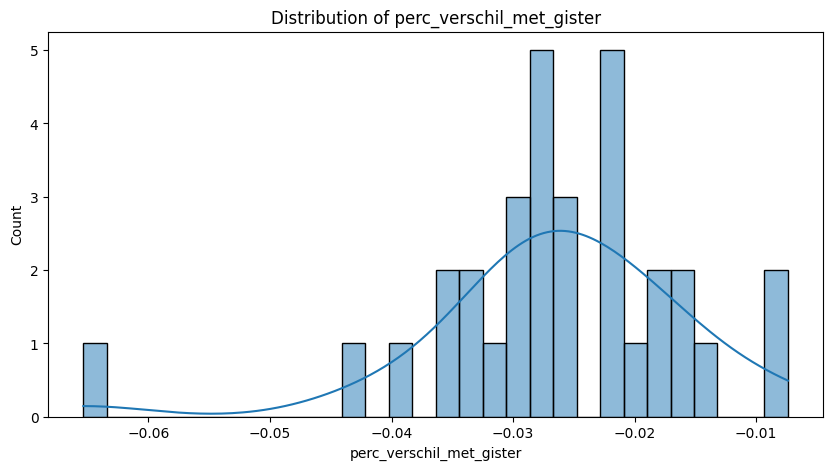

In [32]:
# Plot the distribution of 'perc_verschil_met_gister'
plt.figure(figsize=(10, 5))
sns.histplot(df_export['perc_verschil_met_gister'], kde=True, bins=30)
plt.title('Distribution of perc_verschil_met_gister')
plt.show()

The distribution of 'perc_verschil_met_gister' appears to be approximately normal, with most values centered around -0.02. There are no apparent outliers, which is good for our analysis.

In [33]:
# ANOVA for the remaining categorical variables
categorical_vars = ['leeftijd_plant', 'soort_plant',
                    'locatie_regio', 'extra_omschrijving', 'diepte_plaatsing']
anova_pvalues = {}

for var in categorical_vars:
    categories = df_export[var].unique()
    anova_results = f_oneway(
        *(df_export['perc_verschil_met_gister'][df_export[var] == category] for category in categories))
    anova_pvalues[var] = anova_results.pvalue

anova_pvalues

{'leeftijd_plant': 0.6137362059402917,
 'soort_plant': 0.9900066164296369,
 'locatie_regio': 0.274389938362589,
 'extra_omschrijving': 0.9170040067003715,
 'diepte_plaatsing': 0.691332834258976}

All these p-values are greater than 0.05, which means we fail to reject the null hypothesis that the means of 'perc_verschil_met_gister' are the same across all categories for each of these variables. In other words, it seems that none of these categorical variables have a significant impact on 'perc_verschil_met_gister'.

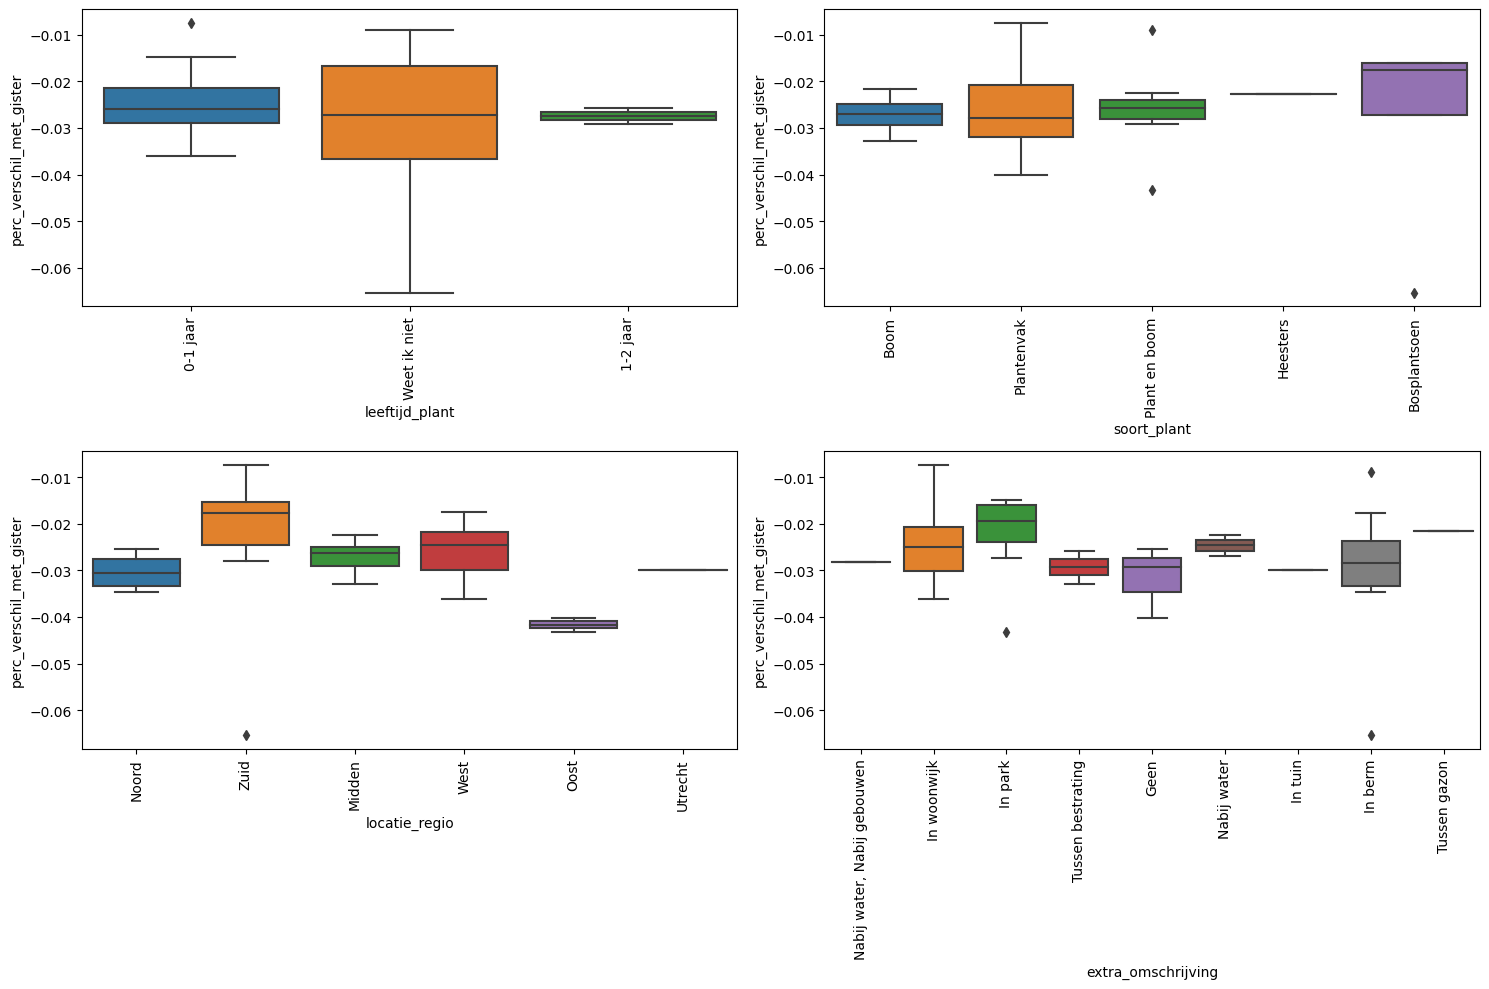

In [34]:
# Create boxplots for each categorical variable
fig, axs = plt.subplots(2, 2, figsize=(15, 10))

for var, ax in zip(categorical_vars, axs.flatten()):
    sns.boxplot(x=var, y='perc_verschil_met_gister', data=df_export, ax=ax)
    ax.tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

## 4.4 Impact van neerslag op permittiviteit

The correlation between 'cum_neerslag_vandaag_gister' and 'gem_meetwaarde' is: 0.45274303335295907


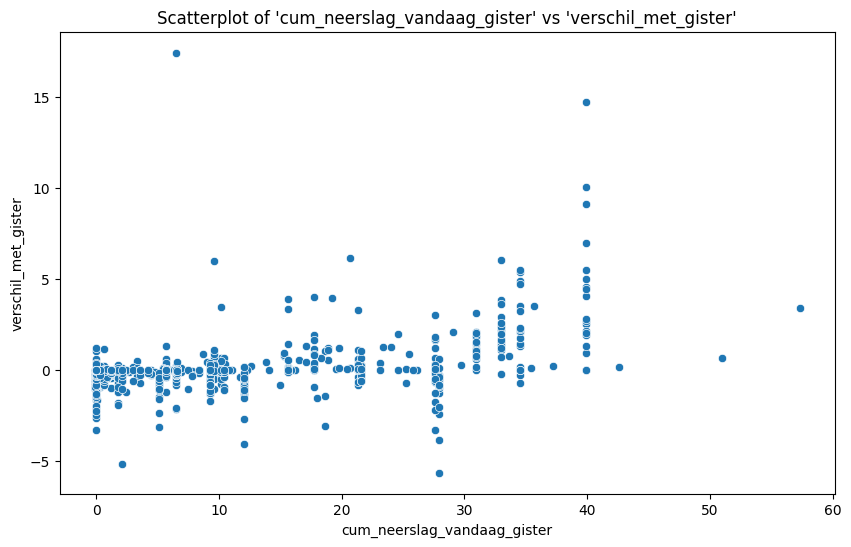

In [35]:
measure = 'verschil_met_gister'
neerslag_col = 'cum_neerslag_vandaag_gister'

df_neerslag = df[df[neerslag_col] > 1]
df_neerslag = df[~df[neerslag_col].isna()]

# Calculate the correlation
correlation, _ = pearsonr(df_neerslag[neerslag_col], df_neerslag[measure])
print(
    f"The correlation between '{neerslag_col}' and 'gem_meetwaarde' is: {correlation}")

# Create a scatterplot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_neerslag, x=neerslag_col, y=measure)
plt.title(f"Scatterplot of '{neerslag_col}' vs '{measure}'")
plt.show()

# 4.5 Bekijk impact van neerslag op meetwaardes per locatie

C:\Users\JSpan\AppData\Roaming\Python\Python311\site-packages\seaborn\axisgrid.py:118: UserWarning:

The figure layout has changed to tight



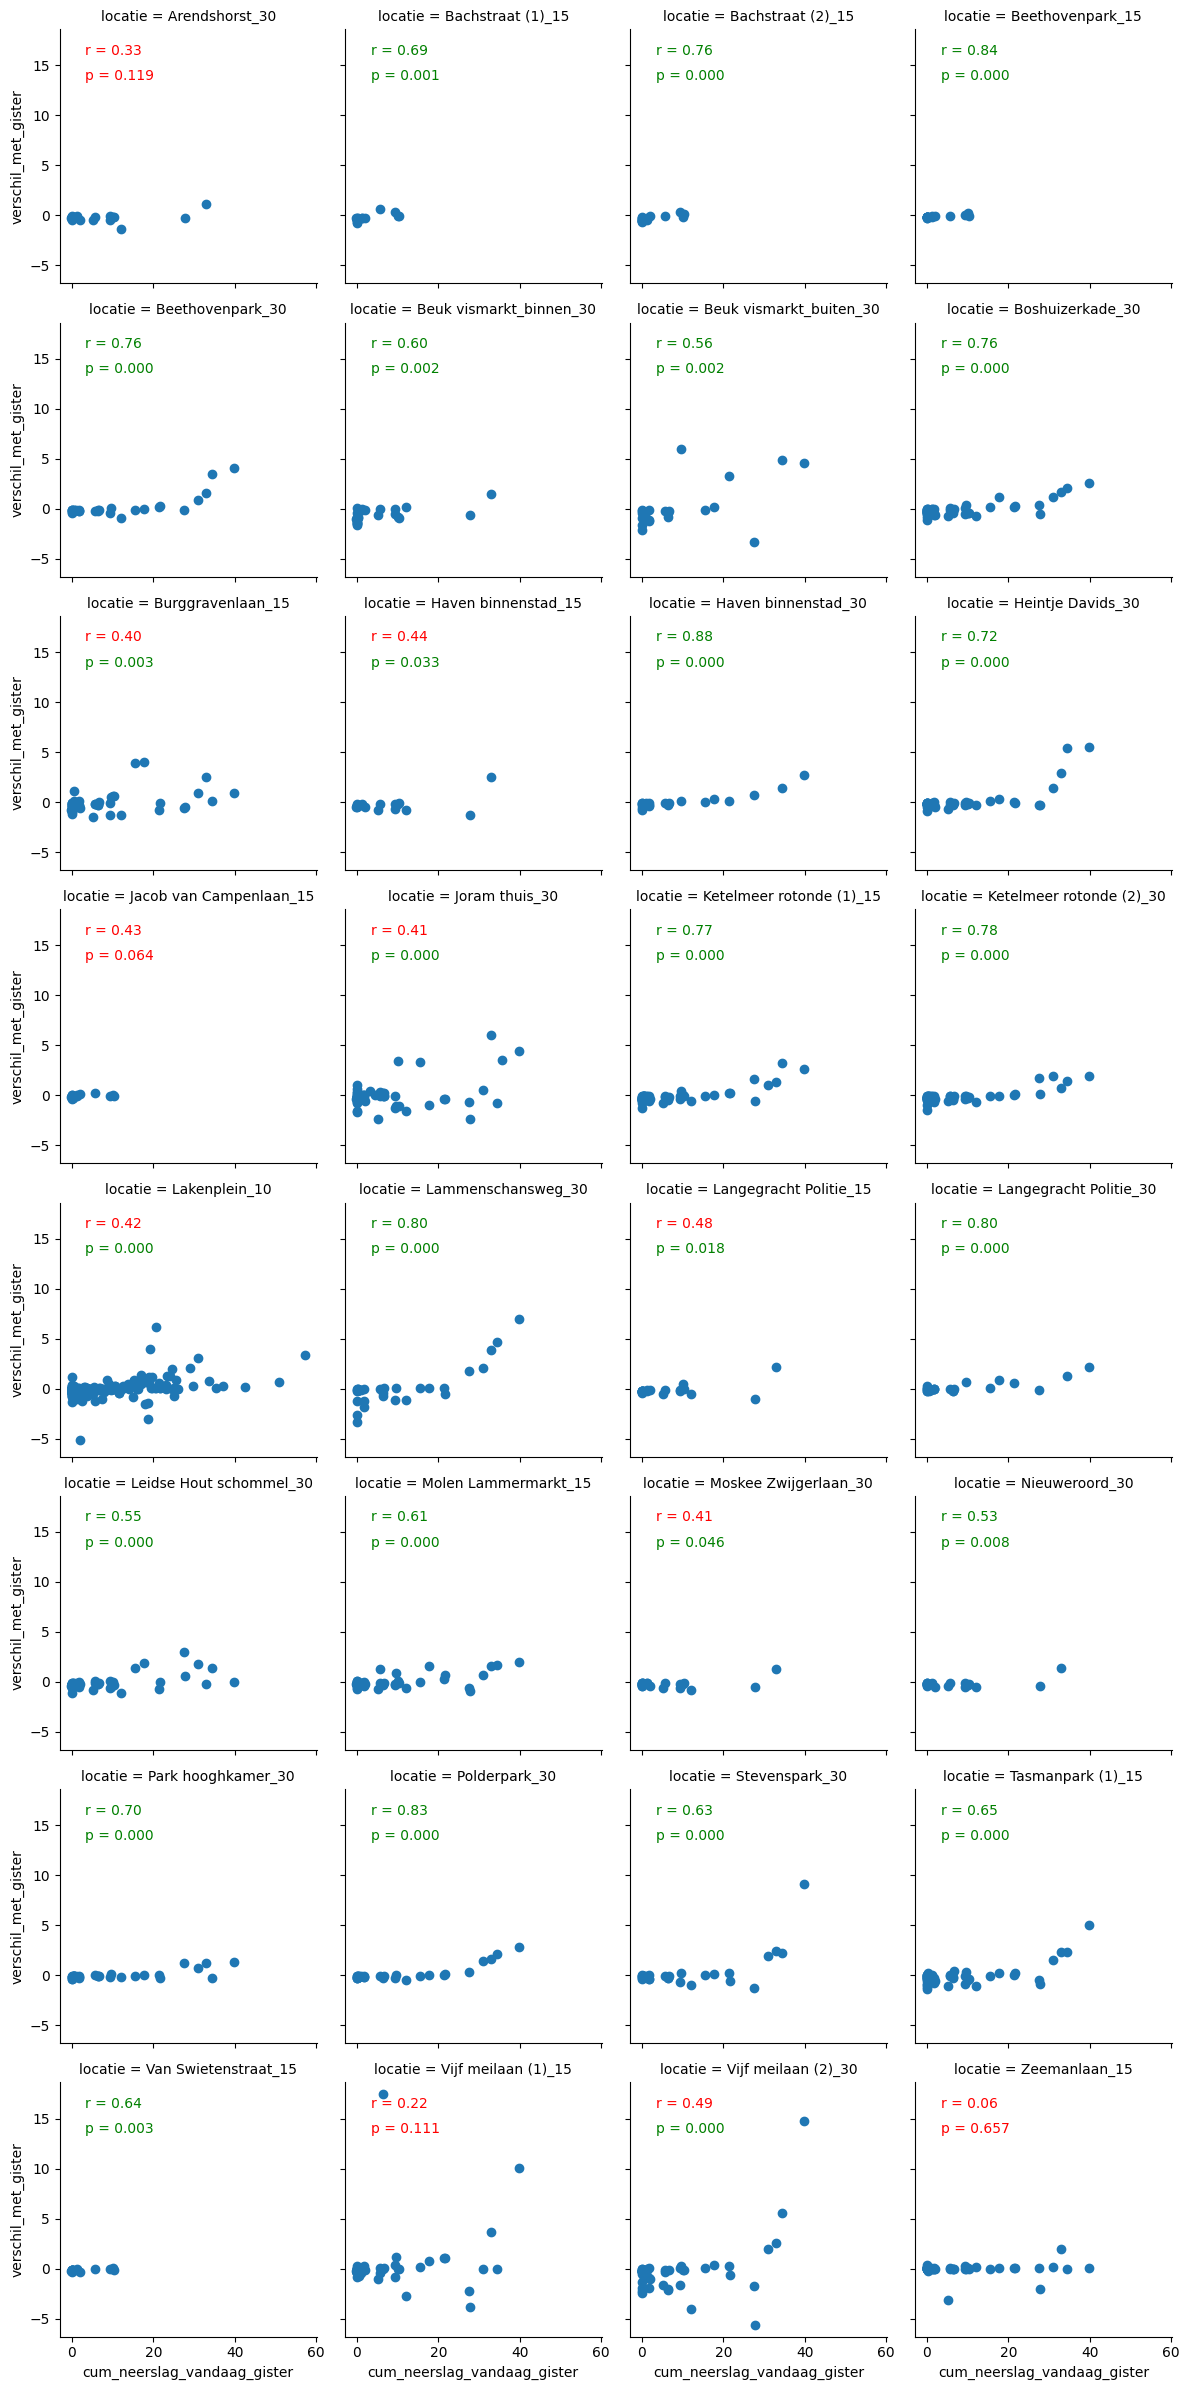

In [36]:
# Define custom scatterplot function
def scatterplot_with_corr_and_pval(x, y, **kwargs):
    # Calculate the correlation and p-value
    correlation, p_value = pearsonr(x, y)
    # Create scatterplot
    ax = plt.gca()
    ax.scatter(x, y, **kwargs)

    # Define colors based on correlation and p-value
    p_color = 'green' if p_value <= 0.05 else 'red'
    r_color = 'green' if abs(correlation) >= 0.5 else 'red'

    # Annotate with correlation coefficient and p-value
    ax.text(0.1, 0.9, f'r = {correlation:.2f}',
            transform=ax.transAxes, color=r_color)
    ax.text(0.1, 0.8, f'p = {p_value:.3f}',
            transform=ax.transAxes, color=p_color)


# Create a scatterplot matrix per location
g = sns.FacetGrid(df_neerslag, col="locatie", col_wrap=4, height=3)
# Create a scatterplot matrix per location
g = g.map(scatterplot_with_corr_and_pval, neerslag_col, measure)

# 4.6 Visualisaties - Verloop meting tov neerslag

In [37]:
df_visual = df[df['datum'] > datetime(2023, 7, 3)].copy()
df_visual.sort_values(by=['locatie', 'datum'], inplace=True)

fig = sensor_visual('gem_meetwaarde', df_visual)
fig.show()

fig = sensor_visual('min_max_gem_meetwaarde', df_visual)
fig.show()

fig = sensor_visual('norm_gem_meetwaarde', df_visual)
fig.show()

# 4.7 Wanneer is er gesproeid?
Ik wil per locatie weten op welke dagen de gem_meetwaarde omhoog gaat ten opzichte van de vorige dag waarbij het diezelfde dag én de dag daarvoor er in totaal niet meer dan 2 mm regen is gevallen. Mijn aanname is dat er op dit moment dan wel gesproeid moet zijn.

In [38]:
# Set the rainfall threshold
rainfall_threshold = 2

# Find the days where gem_waarde increased and the total rainfall was less than or equal to the threshold
df_gesproeid = df[(df['meetwaarde_stijging']) & (
    df['cum_neerslag_vandaag_gister'] <= rainfall_threshold)]

# We only need the location, date, and gem_waarde for the final result
df_gesproeid = df_gesproeid[['locatie', 'datum', 'gem_meetwaarde']]

df_gesproeid

,locatie,datum,gem_meetwaarde
159,Beuk vismarkt_binnen_30,2023-08-10,36.710000
827,Burggravenlaan_15,2023-07-16,7.981429
850,Burggravenlaan_15,2023-07-17,9.105000
1011,Burggravenlaan_15,2023-07-24,7.870000
1014,Heintje Davids_30,2023-07-24,4.614000
2701,Joram thuis_30,2023-06-22,8.312500
2704,Joram thuis_30,2023-06-23,8.630000
2710,Joram thuis_30,2023-06-25,9.224000
693,Joram thuis_30,2023-07-10,9.390000
716,Joram thuis_30,2023-07-11,9.465000


# 5. Powerpoint presentatie

In [39]:
bool_make_powerpoint = True
measure = 'gem_meetwaarde'
folder_path_photo = 'C:/Users/JSpan/OneDrive - ilionx Group BV/03 Projects/17 - Gemeente Leiden - water/Sensor locaties documentatie/'
folder_path_image = 'C:/Users/JSpan/OneDrive - ilionx Group BV/03 Projects/17 - Gemeente Leiden - water/waterleiden/visuals/'

if bool_make_powerpoint:
    prs = make_powerpoint(df_visual, measure, folder_path_photo, folder_path_image)
    
    # Save the PowerPoint presentation
    prs.save("presentation.pptx")
   

Burggravenlaan
Stevenspark
Vijf meilaan (1)
Arendshorst
Lammenschansweg
Jacob van Campenlaan
Beuk vismarkt
Boshuizerkade
Langegracht Politie
Ketelmeer rotonde (2)
Polderpark
Zeemanlaan
Park hooghkamer
Bachstraat (2)
Vijf meilaan (2)
Beethovenpark
Heintje Davids
Nieuweroord
Ketelmeer rotonde (1)
Haven binnenstad
Molen Lammermarkt
Van Swietenstraat
Moskee Zwijgerlaan
Joram thuis
Tasmanpark (1)
Bachstraat (1)
Leidse Hout schommel
Nieuweroord
